LAB 1



Name - Kimi Patle

Class - C1- A1

Roll no. = 07

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import train_test_split

In [ ]:
df = pd.read_csv("Titanic-Dataset.csv")

In [ ]:
df.head( )  ## Starting values

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
df.tail() ## bottom values

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [ ]:
df.shape ## Rows and columms

(891, 12)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
## describing dataset
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [ ]:
df.isnull().sum() ## to identify the missing values
## drop the column when the missing values are more than 60%

## fill the missing values of age by taking mean or median
## fill the values through mode when the missing values are less as in embard

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

# Correlation between variables
corr = df.corr()
corr.Survived.sort_values(ascending=False).head(10)
## run after removing the dataset column name and cabin

In [ ]:
df["Embarked"].unique()

array([ 0.,  1., nan])

In [ ]:
df["Embarked"] = df["Embarked"].replace("S", 0)
df["Embarked"] = df["Embarked"].replace("C", 1)
df["Embarked"] = df["Embarked"].replace("Q", 2)

In [ ]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,0.0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,1.0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,0.0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,0.0
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,0.0


In [ ]:
df["Age"].fillna(df["Age"].median(), inplace = True)

C:\Users\HP\AppData\Local\Temp\ipykernel_9548\687817444.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Age"].fillna(df["Age"].median(), inplace = True)


In [ ]:
df["Embarked"].fillna(df["Embarked"].mode()[0], inplace=True)
df.isnull().sum()
df.drop("Cabin", axis = 1, inplace = True)
df.duplicated().sum()

C:\Users\HP\AppData\Local\Temp\ipykernel_9548\1264720826.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Embarked"].fillna(df["Embarked"].mode()[0], inplace=True)


0

In [ ]:
## df.drop_duplicate(inplace=True)

## if there are duplicate values use this

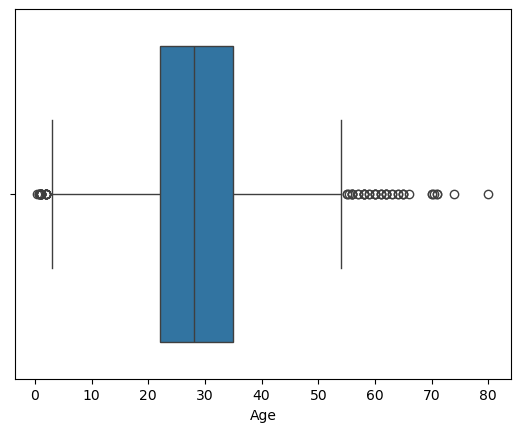

In [ ]:
sns.boxplot(x = df["Age"])
plt.show()

## Outliers - Values outide the range
## We have to remove the outliers to increase the accuracy of our models. Different methods are used to do this

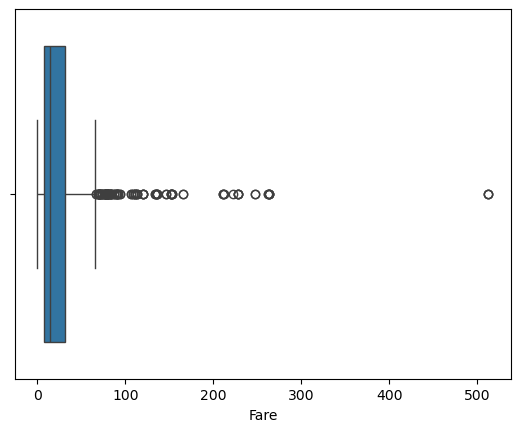

In [ ]:
sns.boxplot(x = df["Fare"])
plt.show()

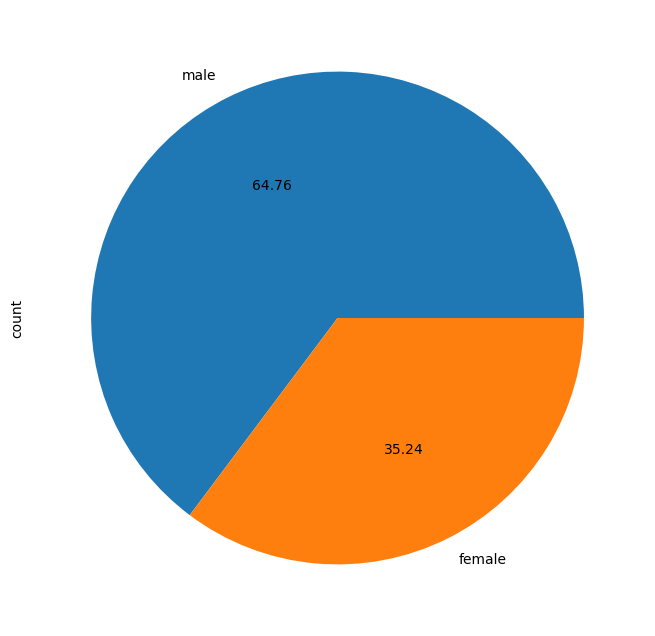

In [ ]:
plt.figure(figsize = (14,8))
df['Sex'].value_counts().plot(kind = "pie", autopct = "%.2f")
plt.show()

In [ ]:
df["Sex"] = df["Sex"].replace("male", 0)
df["Sex"] = df["Sex"].replace("female", 1)

C:\Users\HP\AppData\Local\Temp\ipykernel_9548\4024426784.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["Sex"] = df["Sex"].replace("female", 1)


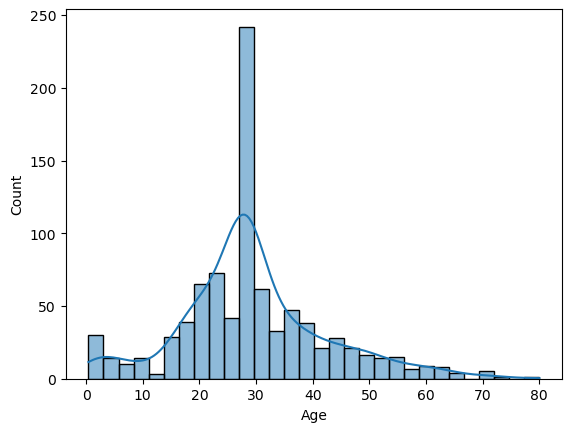

In [ ]:
sns.histplot(df["Age"], kde = True)
plt.show()

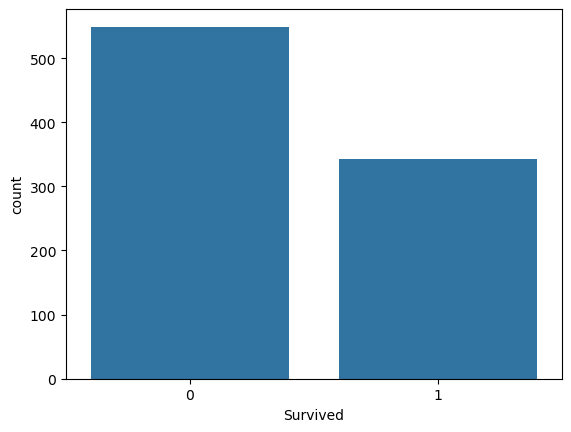

In [ ]:
sns.countplot(x = "Survived", data = df)
plt.show()
# Univarient

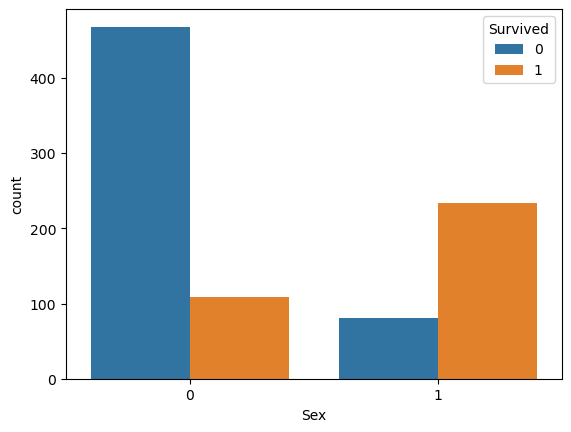

In [ ]:
sns.countplot(x = "Sex", hue= "Survived",  data = df)
plt.show()
# Bivariant graph - Has two variables

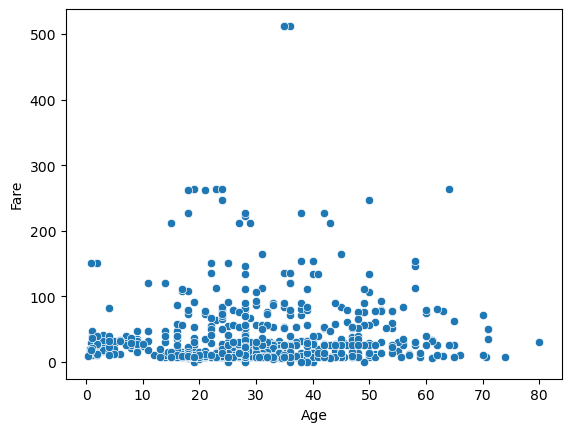

In [ ]:
sns.scatterplot(x = "Age", y = "Fare", data = df)
plt.show()

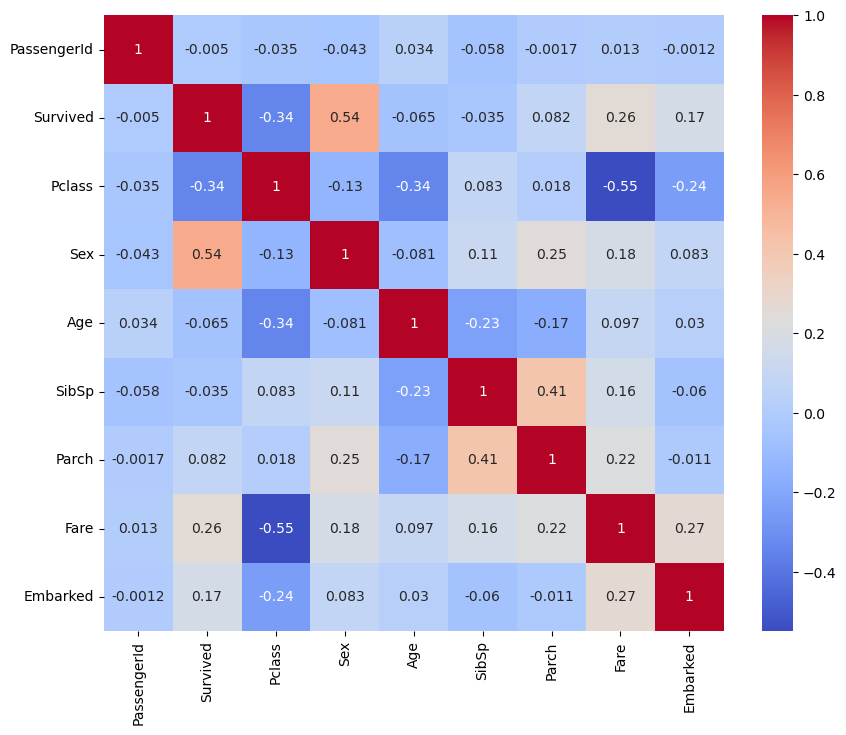

In [ ]:
plt.figure(figsize = (10,8))

numeric_df = df.select_dtypes(include = ['number'])

sns.heatmap(numeric_df.corr(), annot = True, cmap = "coolwarm")
plt.show()

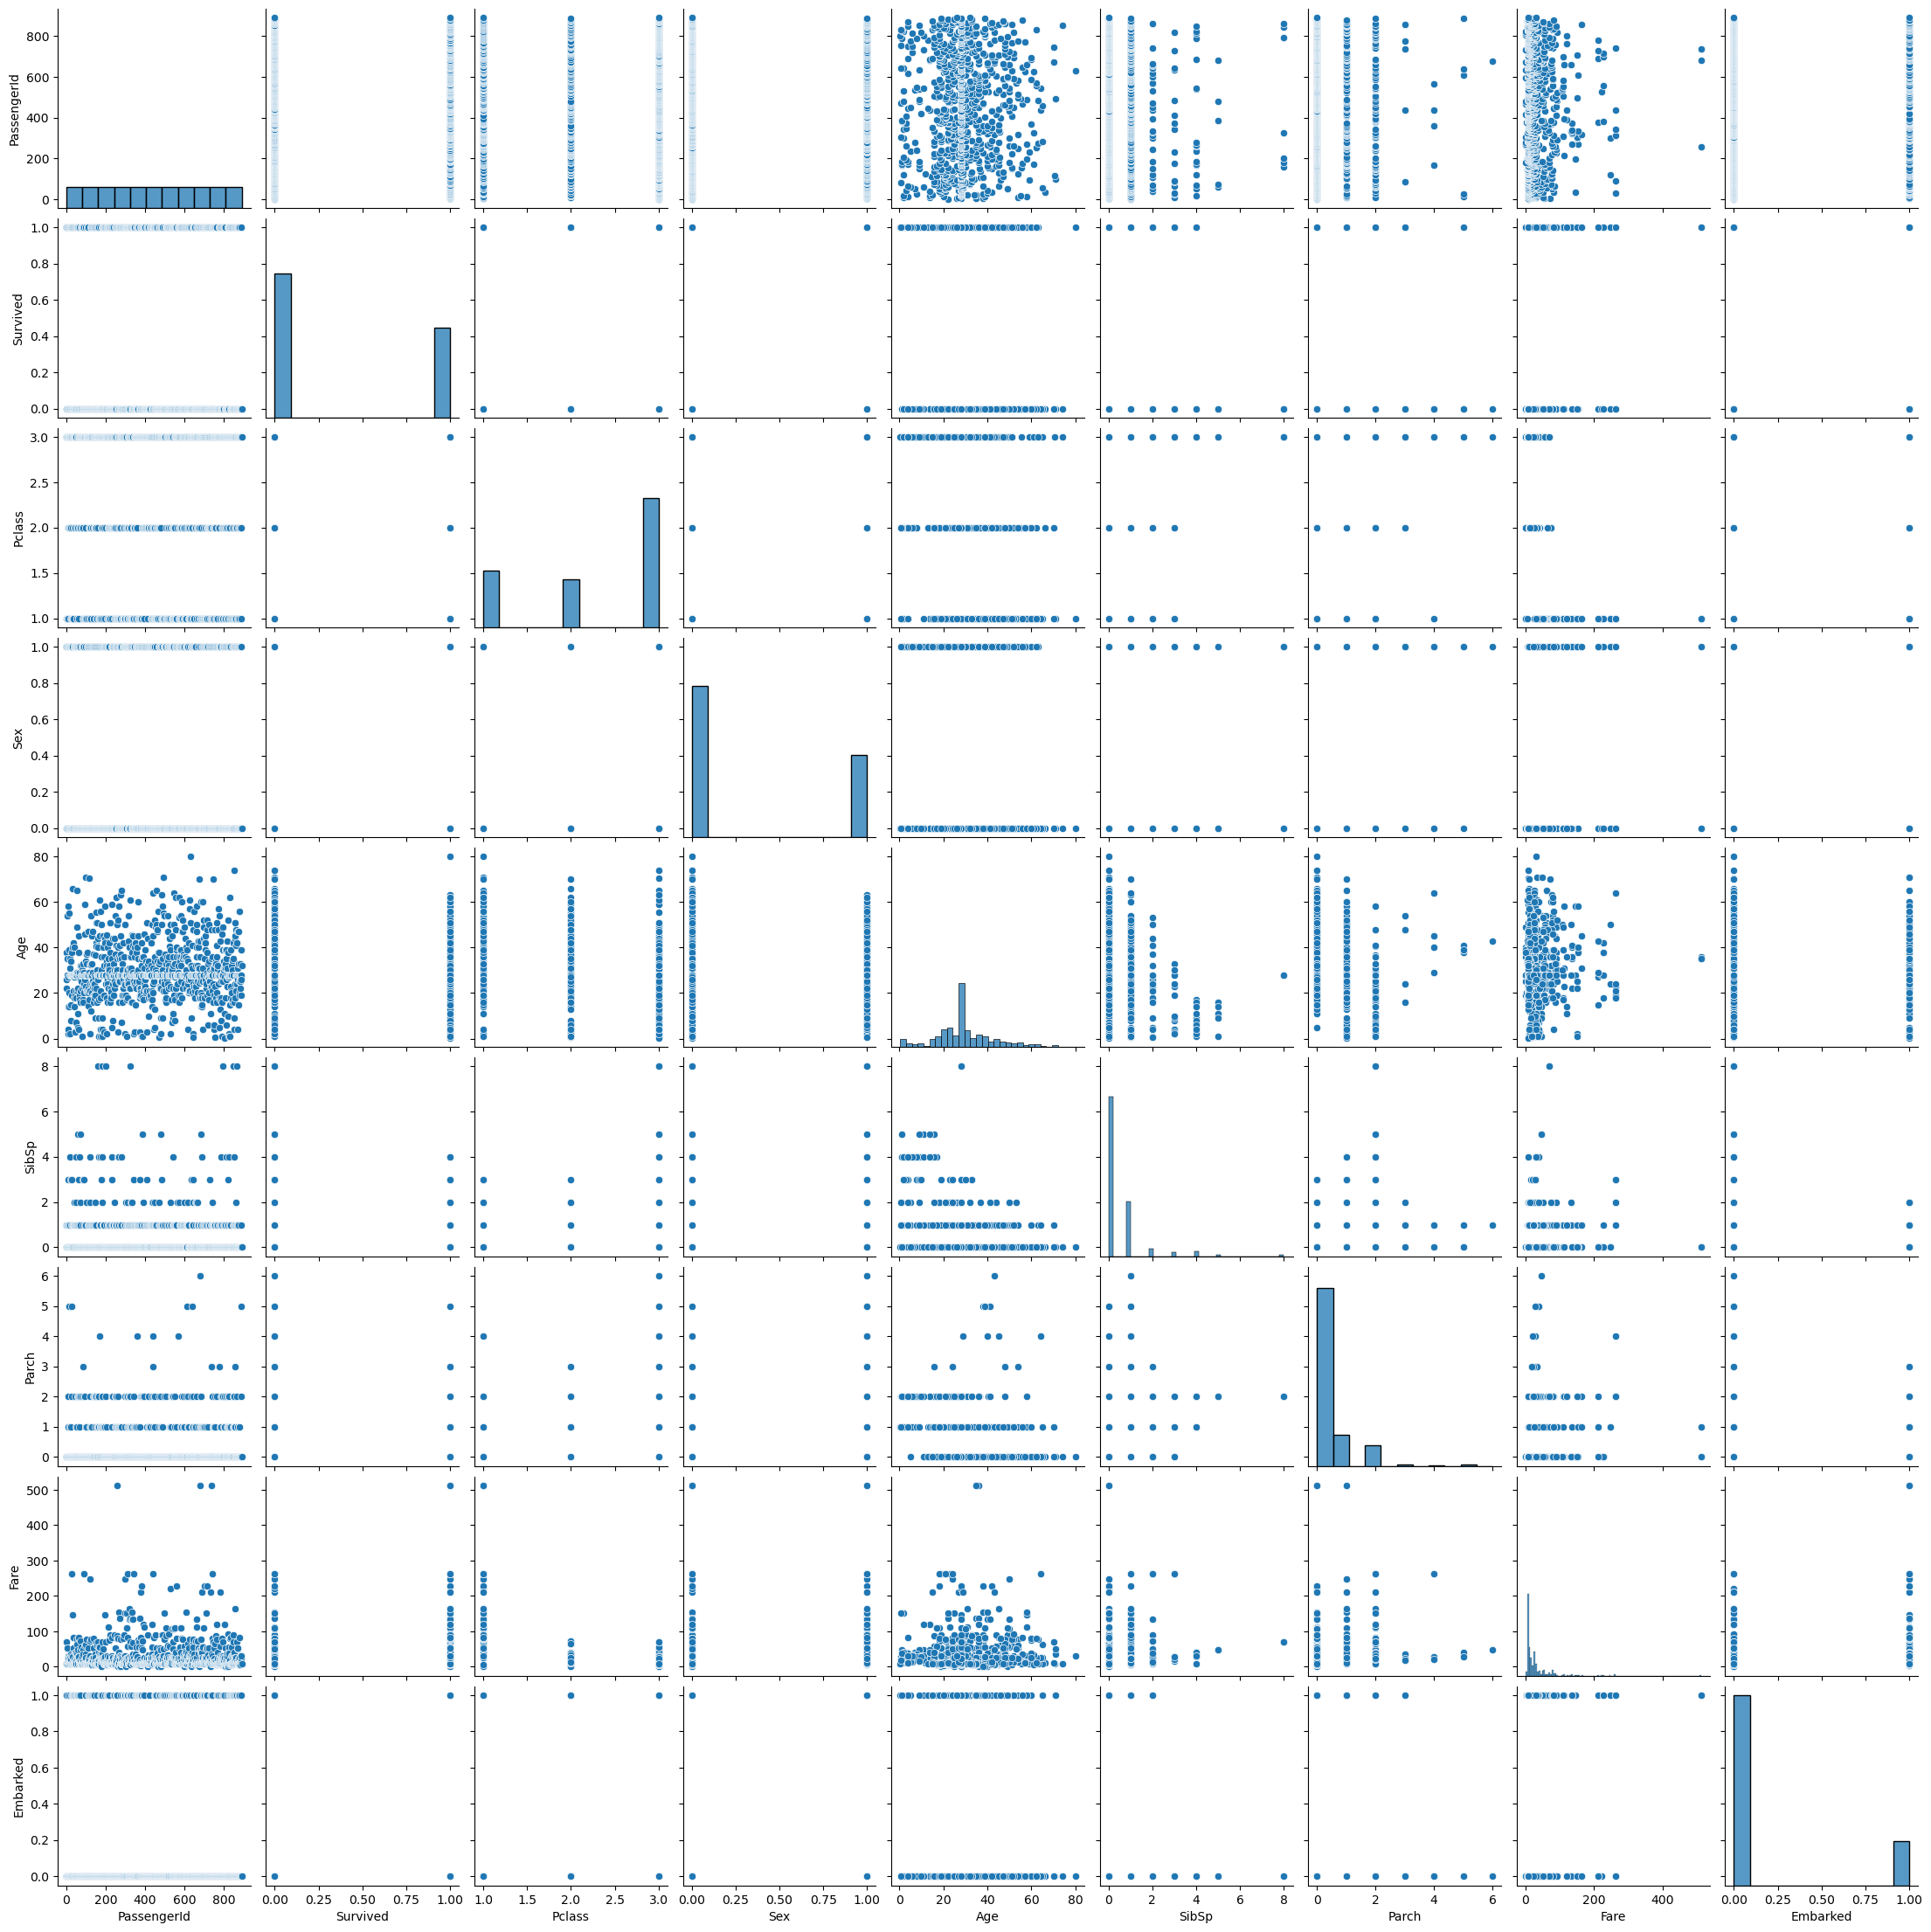

In [ ]:
sns.pairplot(df)
plt.show()

In [ ]:
## Confusion matrix


In [ ]:

scaler = StandardScaler()
df[["Age", "Fare"]] = scaler.fit_transform(df[["Age", "Fare"]])

In [ ]:
X= df.drop("Survived", axis = 1)
y = df["Survived"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,y, test_size = 0.20,

    random_state = 42   ## Overfitting and underfitting of model

)




In [ ]:
print(X_train.shape) ## DATAPOINTS,

print(X_test.shape)

print(y_train.shape)

print(y_test.shape)

(712, 10)
(179, 10)
(712,)
(179,)


In [ ]:
# OUTLIER DETECTION TECHNIQUES

In [ ]:
Q1 = df["Age"].quantile(0.25)
Q3 = df["Age"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5* IQR

df = df[(df["Age"] >= lower) & (df["Age"] <= upper)]


In [ ]:
le = LabelEncoder()
df["Sex"] = le.fit_transform(df["Sex"])

C:\Users\HP\AppData\Local\Temp\ipykernel_9548\1821361045.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Sex"] = le.fit_transform(df["Sex"])
